## Create Game


In [6]:
import gradio as gr
print(gr.__version__)

6.14.0


In [1]:
import sys
from pathlib import Path

# find project root (folder containing 'demos')
ROOT = Path.cwd().resolve()
while not (ROOT / "demos").exists():
    ROOT = ROOT.parent

sys.path.append(str(ROOT))

In [ ]:
from demos.JailbreakAnalysis.JailbreakAnalysisGame import JailbreakGame

game = JailbreakGame(
    model_name="TinyLlama/TinyLlama-1.1B-Chat-v1.0", 
    input_text="i really like shapiq",                    
    mask_strategy="mask",
    segmentation="token",
    device="cuda",
)

Using device: mps


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import shapiq

approx = shapiq.KernelSHAP(
        n=game.n_players,
        random_state=42,
    )
result = approx.approximate(budget=100, game=game)

print(result.values)



/Users/chenwh/Projects/python/shapiq/shapiq-LLM/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


[ 0.          0.42907986  0.33411459  1.1544271   0.73237851 -0.89366322
 -0.44644099]


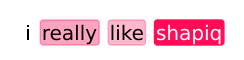

In [5]:
import matplotlib.pyplot as plt

from shapiq.plot.sentence import sentence_plot

tokens = game.input_text.split()
fig, ax = sentence_plot(result.values, tokens, chars_per_line=100, show=False)

plt.show()